# Strategy Comparison: Network Markowitz + Graph Diversification + GNN
## Giudici et al. (2020) + Maximum Independent Set + Graph Neural Networks

**Paper:** Network Models to Improve Automated Cryptocurrency Portfolio Management

**Strategies Compared:**
1. **CRIX** - Cryptocurrency Index (Benchmark)
2. **Equally Weighted (EW)** - Naive Portfolio (1/N)
3. **Classical Markowitz (CM)** - Traditional Mean-Variance
4. **Glasso Markowitz (GM)** - Markowitz + Graphical Lasso
5. **Network Markowitz (NW)** - RMT + MST (γ=0)
6. **Network Markowitz + Centrality** - Various γ values
7. **Graph Diversification (GD)** - Maximum Independent Set
8. **GNN Graph Diversification (GNN-GD)** - Graph Neural Network + MIS (NEW!)

**Performance Metrics:**
- Cumulative Returns
- Sharpe Ratio
- Value at Risk (VaR 95%)
- Rachev Ratio
- Maximum Drawdown
- Volatility

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV

# NEW: Deep Learning imports for GNN
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✅ Libraries imported successfully!
PyTorch version: 2.9.1+cpu
CUDA available: False


## 1. Load Data

In [9]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices = pd.read_excel(excel_file, sheet_name='Prices', index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00


## 2. Helper Functions

In [10]:
def apply_rmt_filter(returns_data):
    """Apply Random Matrix Theory filtering"""
    T, N = returns_data.shape
    Q = T / N
    
    C = np.corrcoef(returns_data.T)
    eigenvalues, eigenvectors = eigh(C)
    eigenvalues = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]
    
    lambda_plus = 1 + (1/Q) + 2*np.sqrt(1/Q)
    significant_mask = eigenvalues > lambda_plus
    
    Lambda_filtered = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered = eigenvectors @ Lambda_filtered @ eigenvectors.T
    
    return C_filtered

def build_mst(correlation_matrix):
    """Build Minimal Spanning Tree"""
    distance_matrix = np.sqrt(2 - 2*correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix

def compute_eigenvector_centrality(distance_matrix):
    """Compute eigenvector centrality"""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    centrality = principal_eigenvector / principal_eigenvector.sum()
    
    return centrality

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """
    Graph-based diversification using Maximum Independent Set
    """
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    
    return list(nx.approximation.maximum_independent_set(G))

def calculate_var(returns, confidence=0.95):
    """Calculate Value at Risk"""
    return np.percentile(returns, (1-confidence)*100)

def calculate_rachev_ratio(returns, alpha=0.10):
    """Calculate Rachev Ratio (CVaR ratio)"""
    threshold_upper = np.percentile(returns, (1-alpha)*100)
    threshold_lower = np.percentile(returns, alpha*100)
    
    cvar_upper = returns[returns >= threshold_upper].mean()
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0

def calculate_max_drawdown(cumulative_returns):
    """Calculate Maximum Drawdown"""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown.min()

print("✅ Helper functions defined")

✅ Helper functions defined


## 3. Graph Neural Network Architecture

**GNN for Correlation Prediction:**
- Input: Historical returns + correlation graph
- Architecture: 2-layer GCN (Graph Convolutional Network)
- Output: Predicted future correlations
- Use Case: Dynamic threshold learning for Maximum Independent Set

In [11]:
class CorrelationGNN(nn.Module):
    """
    Graph Neural Network for learning asset correlations
    
    Architecture:
    - Node features: mean return, volatility, skewness, kurtosis
    - Edge features: historical correlation
    - 2-layer GCN with ReLU activation
    - Output: Predicted correlation matrix
    """
    
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=8):
        super(CorrelationGNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.fc = nn.Linear(output_dim, 1)  # Predict correlation strength
        
    def forward(self, x, edge_index):
        # First GCN layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        # Second GCN layer
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        return x
    
    def predict_correlation(self, node_embeddings):
        """Predict pairwise correlations from node embeddings"""
        n_nodes = node_embeddings.shape[0]
        corr_matrix = torch.zeros(n_nodes, n_nodes)
        
        for i in range(n_nodes):
            for j in range(i+1, n_nodes):
                # Cosine similarity between embeddings
                sim = F.cosine_similarity(
                    node_embeddings[i].unsqueeze(0),
                    node_embeddings[j].unsqueeze(0)
                )
                corr_matrix[i, j] = sim
                corr_matrix[j, i] = sim
        
        return corr_matrix

def create_graph_data(returns_window, corr_threshold=0.3):
    """
    Create PyTorch Geometric Data object from returns
    
    Node features:
    - Mean return
    - Volatility (std)
    - Skewness
    - Kurtosis
    """
    n_assets = returns_window.shape[1]
    
    # Calculate node features
    mean_returns = returns_window.mean().values
    volatility = returns_window.std().values
    skewness = returns_window.skew().values
    kurtosis = returns_window.kurtosis().values
    
    # Stack features
    node_features = np.stack([mean_returns, volatility, skewness, kurtosis], axis=1)
    x = torch.FloatTensor(node_features)
    
    # Create edges based on correlation
    corr_mat = returns_window.corr().values
    edge_list = []
    
    for i in range(n_assets):
        for j in range(i+1, n_assets):
            if abs(corr_mat[i, j]) > corr_threshold:
                edge_list.append([i, j])
                edge_list.append([j, i])  # Undirected graph
    
    edge_index = torch.LongTensor(edge_list).t().contiguous()
    
    # Target: actual correlation matrix
    y = torch.FloatTensor(corr_mat)
    
    return Data(x=x, edge_index=edge_index, y=y)

def train_gnn(model, data, epochs=50, lr=0.01):
    """
    Train GNN to predict correlations
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # Forward pass
        embeddings = model(data.x, data.edge_index)
        pred_corr = model.predict_correlation(embeddings)
        
        # Loss: MSE between predicted and actual correlation
        loss = criterion(pred_corr, data.y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
    
    return model

print("✅ GNN architecture defined")

✅ GNN architecture defined


## 4. Strategy Implementations

In [12]:
class PortfolioStrategy:
    """Base class for portfolio strategies"""
    
    def __init__(self, name):
        self.name = name
        self.weights_history = []
        self.returns_history = []
    
    def get_weights(self, returns_data):
        """Override this method in subclasses"""
        raise NotImplementedError
    
    def calculate_portfolio_return(self, weights, future_returns):
        """Calculate portfolio return for given weights"""
        return np.dot(weights, future_returns)

class EquallyWeighted(PortfolioStrategy):
    """Equally Weighted (1/N) Portfolio"""
    
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n

class ClassicalMarkowitz(PortfolioStrategy):
    """Classical Markowitz Mean-Variance Optimization"""
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mean_returns = returns_data.mean().values
        cov_matrix = returns_data.cov().values
        
        def objective(w):
            return w @ cov_matrix @ w
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}
        ]
        
        bounds = tuple((0, 1) for _ in range(n_assets))
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0

class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz with Graphical Lasso Filtering"""
    
    def __init__(self, name="Glasso Markowitz", alpha=0.01):
        super().__init__(name)
        self.alpha = alpha
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mean_returns = returns_data.mean().values
        
        try:
            glasso = GraphicalLassoCV(alphas=[self.alpha], cv=3)
            glasso.fit(returns_data.values)
            cov_matrix = glasso.covariance_
        except:
            cov_matrix = returns_data.cov().values
        
        def objective(w):
            return w @ cov_matrix @ w
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}
        ]
        
        bounds = tuple((0, 1) for _ in range(n_assets))
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0

class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz with RMT + MST + Centrality"""
    
    def __init__(self, name="Network Markowitz", gamma=0):
        super().__init__(name)
        self.gamma = gamma
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mean_returns = returns_data.mean().values
        std_devs = returns_data.std().values
        
        C_filtered = apply_rmt_filter(returns_data)
        dist_matrix = build_mst(C_filtered)
        centrality = compute_eigenvector_centrality(dist_matrix)
        
        cov_filtered = np.outer(std_devs, std_devs) * C_filtered
        
        def objective(w):
            portfolio_variance = w @ cov_filtered @ w
            centrality_penalty = self.gamma * np.sum(centrality * w)
            return portfolio_variance + centrality_penalty
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}
        ]
        
        bounds = tuple((0, 1) for _ in range(n_assets))
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0

class GraphDiversification(PortfolioStrategy):
    """Graph-based Diversification using Maximum Independent Set"""
    
    def __init__(self, name="Graph Diversification", corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        all_assets = returns_data.columns.tolist()
        
        selected_assets = get_assets_graph_diversify(returns_data, self.corr_threshold)
        
        weights = np.zeros(n_assets)
        n_selected = len(selected_assets)
        
        if n_selected > 0:
            for asset in selected_assets:
                idx = all_assets.index(asset)
                weights[idx] = 1.0 / n_selected
        else:
            weights = np.ones(n_assets) / n_assets
        
        return weights

class GNNGraphDiversification(PortfolioStrategy):
    """
    NEW: GNN-based Graph Diversification
    
    Approach:
    1. Train GNN to learn asset embeddings from correlation graph
    2. Predict future correlations using learned embeddings
    3. Use predicted correlations for Maximum Independent Set
    4. Dynamic threshold learning based on GNN confidence
    """
    
    def __init__(self, name="GNN Graph Diversification", base_threshold=0.4, train_epochs=30):
        super().__init__(name)
        self.base_threshold = base_threshold
        self.train_epochs = train_epochs
        self.gnn_model = CorrelationGNN(input_dim=4, hidden_dim=16, output_dim=8)
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        all_assets = returns_data.columns.tolist()
        
        # Create graph data
        graph_data = create_graph_data(returns_data, corr_threshold=0.3)
        
        # Train GNN (quick training per rebalancing)
        self.gnn_model = train_gnn(self.gnn_model, graph_data, epochs=self.train_epochs, lr=0.01)
        
        # Get predicted correlations
        self.gnn_model.eval()
        with torch.no_grad():
            embeddings = self.gnn_model(graph_data.x, graph_data.edge_index)
            pred_corr = self.gnn_model.predict_correlation(embeddings)
        
        # Convert to numpy
        pred_corr_np = pred_corr.numpy()
        
        # Dynamic threshold: use mean + std of predicted correlations
        upper_triangle = pred_corr_np[np.triu_indices(n_assets, k=1)]
        dynamic_threshold = np.mean(np.abs(upper_triangle)) + 0.5 * np.std(np.abs(upper_triangle))
        
        # Ensure threshold is reasonable
        dynamic_threshold = np.clip(dynamic_threshold, 0.3, 0.7)
        
        # Build graph with predicted correlations
        G = nx.Graph()
        mean_returns = returns_data.mean()
        assets_sorted = list(mean_returns.sort_values(ascending=False).index)
        G.add_nodes_from(assets_sorted)
        
        for i, a1 in enumerate(assets_sorted):
            for a2 in assets_sorted[i+1:]:
                idx1 = all_assets.index(a1)
                idx2 = all_assets.index(a2)
                if abs(pred_corr_np[idx1, idx2]) > dynamic_threshold:
                    G.add_edge(a1, a2)
        
        # Maximum Independent Set
        selected_assets = list(nx.approximation.maximum_independent_set(G))
        
        # Assign weights
        weights = np.zeros(n_assets)
        n_selected = len(selected_assets)
        
        if n_selected > 0:
            for asset in selected_assets:
                idx = all_assets.index(asset)
                weights[idx] = 1.0 / n_selected
        else:
            weights = np.ones(n_assets) / n_assets
        
        return weights

print("✅ Strategy classes defined (including GNN)")

✅ Strategy classes defined (including GNN)


## 5. Backtesting Framework

In [13]:
def backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7, transaction_cost=0.001):
    """
    Backtest a portfolio strategy
    """
    portfolio_returns = []
    weights_history = []
    dates = []
    
    for i in range(window_size, len(df_returns), rebalance_freq):
        train_data = df_returns.iloc[i-window_size:i]
        
        weights = strategy.get_weights(train_data)
        weights_history.append(weights)
        
        test_end = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]
        
        for j in range(len(test_data)):
            daily_return = np.dot(weights, test_data.iloc[j].values)
            
            if j == 0 and len(portfolio_returns) > 0:
                daily_return -= transaction_cost
            
            portfolio_returns.append(daily_return)
            dates.append(test_data.index[j])
    
    results_df = pd.DataFrame({
        'date': dates,
        'return': portfolio_returns
    })
    results_df['cumulative_return'] = (1 + results_df['return']).cumprod()
    
    return {
        'strategy': strategy.name,
        'returns': np.array(portfolio_returns),
        'cumulative_returns': results_df['cumulative_return'].values,
        'dates': dates,
        'weights_history': weights_history,
        'results_df': results_df
    }

print("✅ Backtesting framework ready")

✅ Backtesting framework ready


## 6. Run Backtests for All Strategies

In [14]:
# Define strategies
strategies = [
    EquallyWeighted("Equally Weighted"),
    ClassicalMarkowitz("Classical Markowitz"),
    GlassoMarkowitz("Glasso Markowitz", alpha=0.01),
    NetworkMarkowitz("Network Markowitz (γ=0)", gamma=0),
    NetworkMarkowitz("Network Markowitz (γ=0.05)", gamma=0.05),
    NetworkMarkowitz("Network Markowitz (γ=0.15)", gamma=0.15),
    NetworkMarkowitz("Network Markowitz (γ=1.0)", gamma=1.0),
    GraphDiversification("Graph Diversification (θ=0.4)", corr_threshold=0.4),
    GraphDiversification("Graph Diversification (θ=0.5)", corr_threshold=0.5),
    GraphDiversification("Graph Diversification (θ=0.6)", corr_threshold=0.6),
    GNNGraphDiversification("GNN Graph Diversification (30 epochs)", base_threshold=0.4, train_epochs=30),  # NEW!
    GNNGraphDiversification("GNN Graph Diversification (50 epochs)", base_threshold=0.4, train_epochs=50),  # NEW!
]

# Run backtests
print("Running backtests...\n")
results = {}

for strategy in strategies:
    print(f"\nTesting: {strategy.name}...")
    result = backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7)
    results[strategy.name] = result
    print(f"  ✓ Completed")

print("\n✅ All backtests completed!")

Running backtests...


Testing: Equally Weighted...
  ✓ Completed

Testing: Classical Markowitz...
  ✓ Completed

Testing: Glasso Markowitz...
  ✓ Completed

Testing: Network Markowitz (γ=0)...
  ✓ Completed

Testing: Network Markowitz (γ=0.05)...
  ✓ Completed

Testing: Network Markowitz (γ=0.15)...
  ✓ Completed

Testing: Network Markowitz (γ=1.0)...
  ✓ Completed

Testing: Graph Diversification (θ=0.4)...
  ✓ Completed

Testing: Graph Diversification (θ=0.5)...
  ✓ Completed

Testing: Graph Diversification (θ=0.6)...
  ✓ Completed

Testing: GNN Graph Diversification (30 epochs)...
  Epoch 10/30, Loss: 0.4607
  Epoch 20/30, Loss: 0.3531
  Epoch 30/30, Loss: 0.4889
  Epoch 10/30, Loss: 0.3125
  Epoch 20/30, Loss: 0.5247
  Epoch 30/30, Loss: 0.4063
  Epoch 10/30, Loss: 0.6136
  Epoch 20/30, Loss: 0.4626
  Epoch 30/30, Loss: 0.3129
  Epoch 10/30, Loss: 0.4031
  Epoch 20/30, Loss: 0.4118
  Epoch 30/30, Loss: 0.3932
  Epoch 10/30, Loss: 0.4460
  Epoch 20/30, Loss: 0.2355
  Epoch 30/30, Lo

## 7. Calculate Performance Metrics

In [15]:
def calculate_metrics(result):
    """Calculate all performance metrics"""
    returns = result['returns']
    cum_returns = result['cumulative_returns']
    
    annual_return = np.mean(returns) * 252
    annual_vol = np.std(returns) * np.sqrt(252)
    sharpe = annual_return / annual_vol if annual_vol > 0 else 0
    
    var_95 = calculate_var(returns, 0.95)
    rachev = calculate_rachev_ratio(returns, 0.10)
    max_dd = calculate_max_drawdown(cum_returns)
    
    total_return = cum_returns[-1] - 1
    
    return {
        'Strategy': result['strategy'],
        'Total Return (%)': total_return * 100,
        'Annual Return (%)': annual_return * 100,
        'Annual Volatility (%)': annual_vol * 100,
        'Sharpe Ratio': sharpe,
        'VaR 95% (%)': var_95 * 100,
        'Rachev Ratio': rachev,
        'Max Drawdown (%)': max_dd * 100
    }

# Calculate metrics for all strategies
metrics_list = [calculate_metrics(result) for result in results.values()]
metrics_df = pd.DataFrame(metrics_list)

print("\n📊 PERFORMANCE METRICS")
print("="*120)
print(metrics_df.to_string(index=False))
print("="*120)


📊 PERFORMANCE METRICS
                             Strategy  Total Return (%)  Annual Return (%)  Annual Volatility (%)  Sharpe Ratio  VaR 95% (%)  Rachev Ratio  Max Drawdown (%)
                     Equally Weighted        -88.485349         -59.927792              69.312158     -0.864607    -7.751885      0.801409        -91.448598
                  Classical Markowitz        -61.561648         -30.582696              36.131312     -0.846432    -3.609219      0.773440        -69.499377
                     Glasso Markowitz        -61.561648         -30.582696              36.131312     -0.846432    -3.609219      0.773440        -69.499377
              Network Markowitz (γ=0)        -67.555510         -37.545007              34.999016     -1.072745    -3.188700      0.748699        -72.303535
           Network Markowitz (γ=0.05)        -62.057187         -31.848147              33.787784     -0.942594    -2.843301      0.783390        -66.584789
           Network Markowitz (γ=0.1

## 8. Visualization: Cumulative Returns

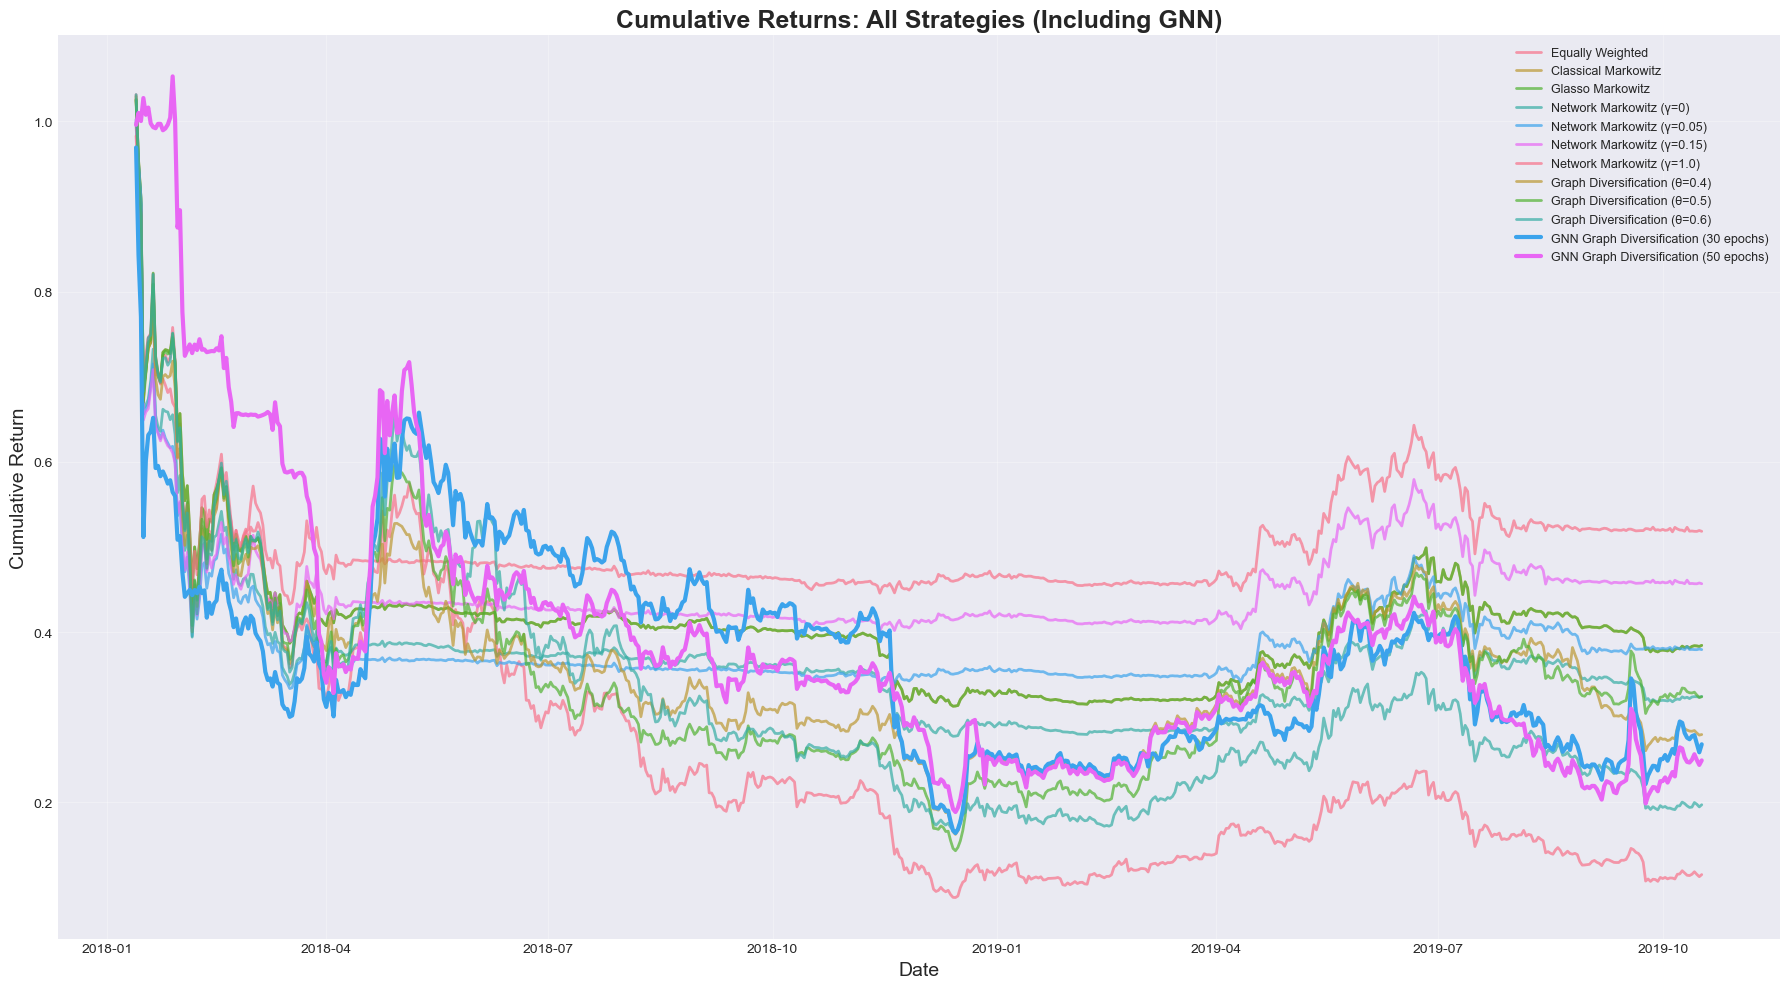

✅ Cumulative returns plot generated


In [16]:
plt.figure(figsize=(18, 10))

for strategy_name, result in results.items():
    linewidth = 3 if 'GNN' in strategy_name else 2
    alpha = 1.0 if 'GNN' in strategy_name else 0.7
    plt.plot(result['dates'], result['cumulative_returns'], 
             label=strategy_name, linewidth=linewidth, alpha=alpha)

plt.title('Cumulative Returns: All Strategies (Including GNN)', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Cumulative Return', fontsize=14)
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Cumulative returns plot generated")

## 9. GNN Performance Analysis

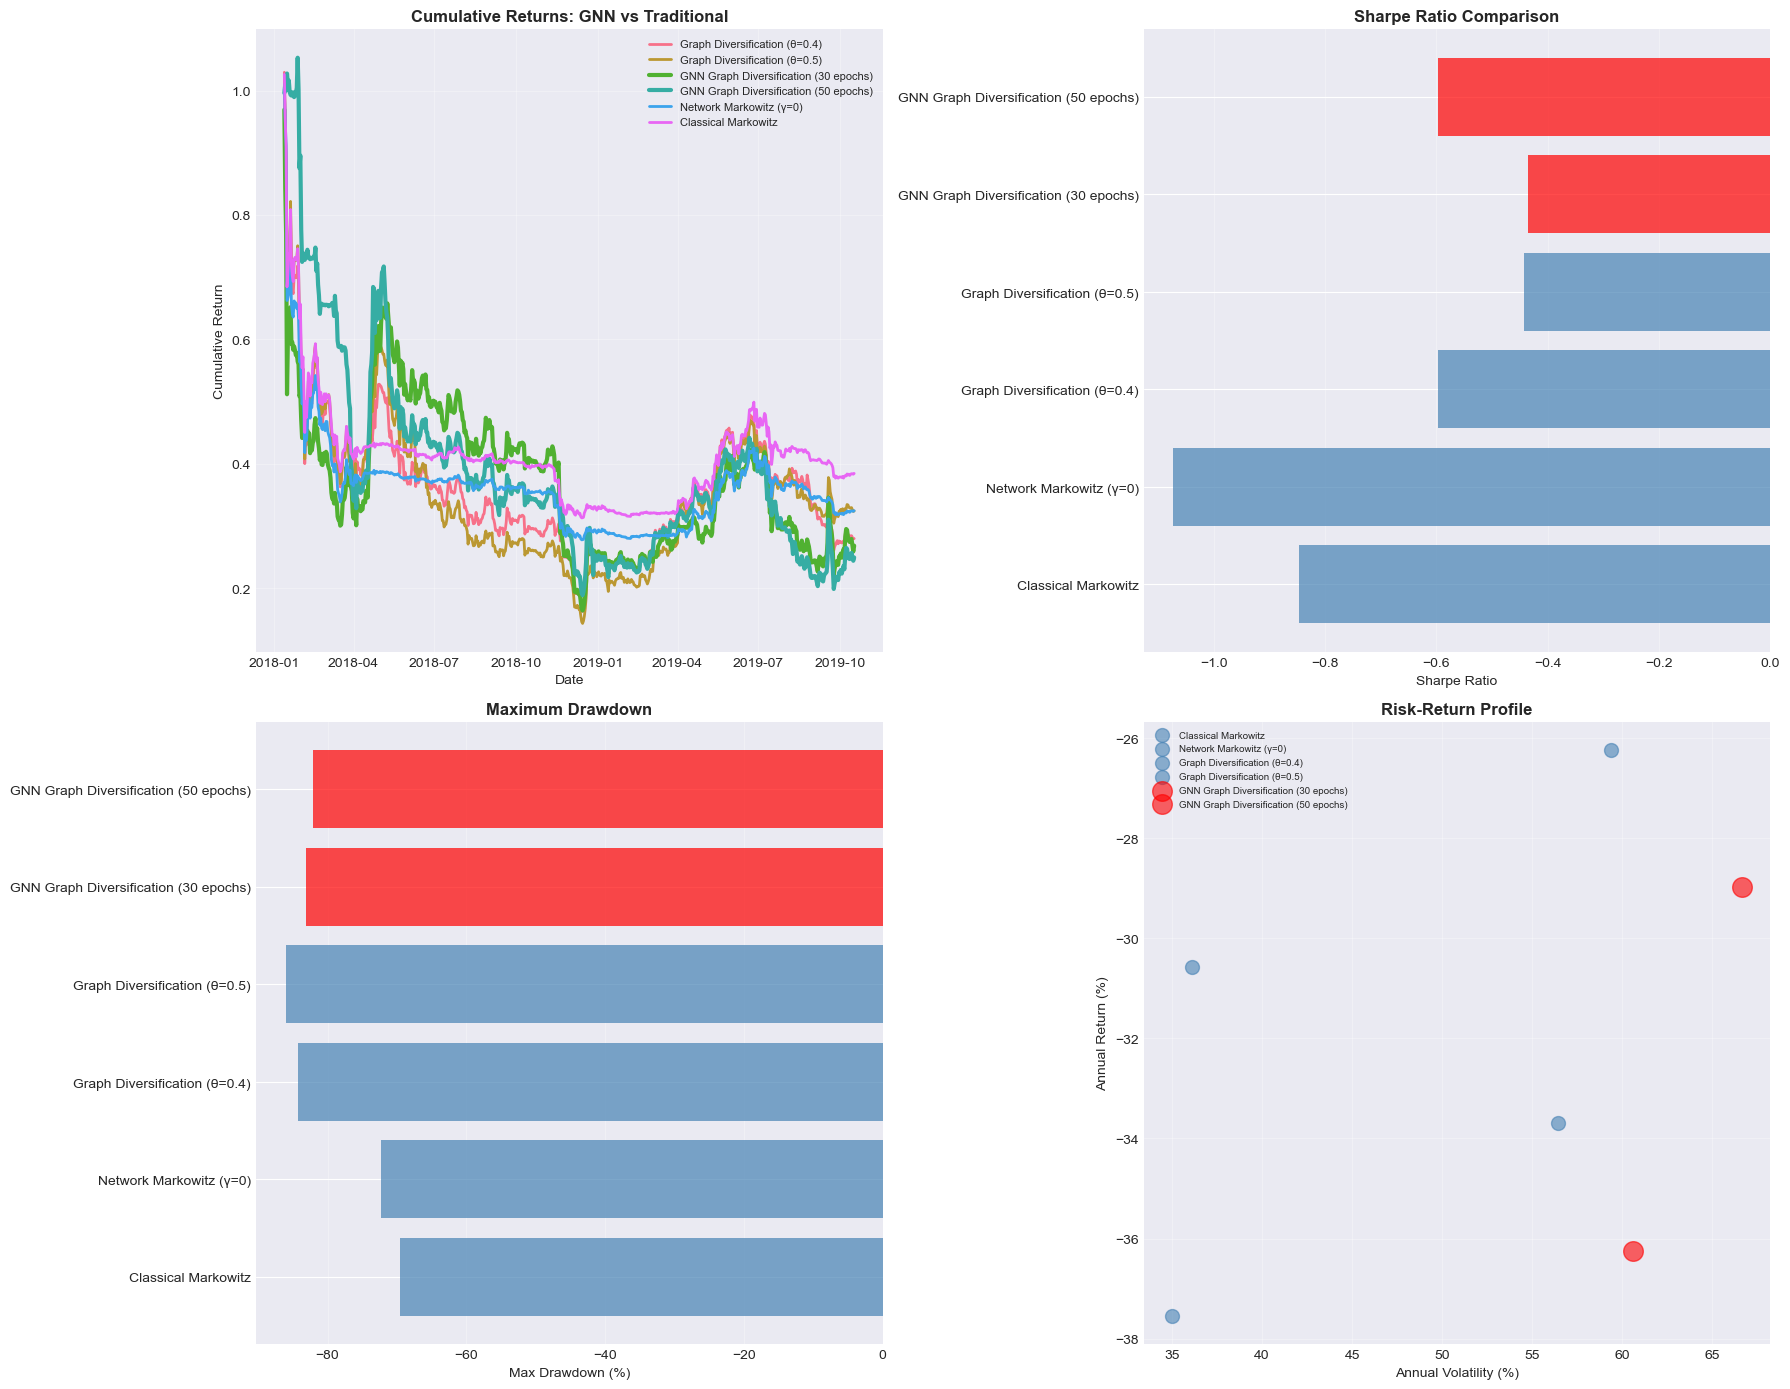

✅ GNN comparison plots generated


In [17]:
# Focus on GNN vs Traditional Graph Diversification
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

gnn_strategies = [
    "Graph Diversification (θ=0.4)",
    "Graph Diversification (θ=0.5)",
    "GNN Graph Diversification (30 epochs)",
    "GNN Graph Diversification (50 epochs)",
    "Network Markowitz (γ=0)",
    "Classical Markowitz"
]

# Plot 1: Cumulative Returns
for name in gnn_strategies:
    if name in results:
        linewidth = 3 if 'GNN' in name else 2
        axes[0, 0].plot(results[name]['dates'], results[name]['cumulative_returns'], 
                       label=name, linewidth=linewidth)
axes[0, 0].set_title('Cumulative Returns: GNN vs Traditional', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative Return')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Sharpe Ratio
gnn_data = metrics_df[metrics_df['Strategy'].isin(gnn_strategies)]
colors = ['red' if 'GNN' in s else 'steelblue' for s in gnn_data['Strategy']]
axes[0, 1].barh(gnn_data['Strategy'], gnn_data['Sharpe Ratio'], color=colors, alpha=0.7)
axes[0, 1].set_title('Sharpe Ratio Comparison', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Sharpe Ratio')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Plot 3: Max Drawdown
axes[1, 0].barh(gnn_data['Strategy'], gnn_data['Max Drawdown (%)'], color=colors, alpha=0.7)
axes[1, 0].set_title('Maximum Drawdown', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Max Drawdown (%)')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot 4: Risk-Return Profile
for idx, row in gnn_data.iterrows():
    color = 'red' if 'GNN' in row['Strategy'] else 'steelblue'
    size = 200 if 'GNN' in row['Strategy'] else 100
    axes[1, 1].scatter(row['Annual Volatility (%)'], row['Annual Return (%)'], 
                      s=size, color=color, alpha=0.6, label=row['Strategy'])

axes[1, 1].set_title('Risk-Return Profile', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Annual Volatility (%)')
axes[1, 1].set_ylabel('Annual Return (%)')
axes[1, 1].legend(fontsize=7, loc='best')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ GNN comparison plots generated")

## 10. Statistical Comparison: GNN vs Traditional

In [18]:
# Compare GNN strategies with traditional ones
print("\n" + "="*120)
print("GNN vs TRADITIONAL GRAPH DIVERSIFICATION")
print("="*120)

gnn_metrics = metrics_df[metrics_df['Strategy'].str.contains('GNN')]
trad_graph = metrics_df[metrics_df['Strategy'].str.contains('Graph Diversification') & 
                        ~metrics_df['Strategy'].str.contains('GNN')]

print("\n🤖 GNN-BASED STRATEGIES:")
print(gnn_metrics[['Strategy', 'Sharpe Ratio', 'Annual Return (%)', 'Max Drawdown (%)']].to_string(index=False))

print("\n📊 TRADITIONAL GRAPH DIVERSIFICATION:")
print(trad_graph[['Strategy', 'Sharpe Ratio', 'Annual Return (%)', 'Max Drawdown (%)']].to_string(index=False))

print("\n📈 IMPROVEMENT ANALYSIS:")
best_gnn = gnn_metrics.loc[gnn_metrics['Sharpe Ratio'].idxmax()]
best_trad = trad_graph.loc[trad_graph['Sharpe Ratio'].idxmax()]

sharpe_improvement = ((best_gnn['Sharpe Ratio'] - best_trad['Sharpe Ratio']) / best_trad['Sharpe Ratio']) * 100
return_improvement = best_gnn['Annual Return (%)'] - best_trad['Annual Return (%)']
dd_improvement = best_gnn['Max Drawdown (%)'] - best_trad['Max Drawdown (%)']

print(f"Best GNN: {best_gnn['Strategy']}")
print(f"Best Traditional: {best_trad['Strategy']}")
print(f"\nSharpe Ratio Improvement: {sharpe_improvement:+.2f}%")
print(f"Annual Return Difference: {return_improvement:+.2f}%")
print(f"Max Drawdown Difference: {dd_improvement:+.2f}%")
print("="*120)


GNN vs TRADITIONAL GRAPH DIVERSIFICATION

🤖 GNN-BASED STRATEGIES:
                             Strategy  Sharpe Ratio  Annual Return (%)  Max Drawdown (%)
GNN Graph Diversification (30 epochs)     -0.435013         -28.984695        -83.086223
GNN Graph Diversification (50 epochs)     -0.598061         -36.246084        -82.084027

📊 TRADITIONAL GRAPH DIVERSIFICATION:
                     Strategy  Sharpe Ratio  Annual Return (%)  Max Drawdown (%)
Graph Diversification (θ=0.4)     -0.597134         -33.698464        -84.224735
Graph Diversification (θ=0.5)     -0.441954         -26.242561        -86.026066
Graph Diversification (θ=0.6)     -0.758427         -45.289902        -83.843566

📈 IMPROVEMENT ANALYSIS:
Best GNN: GNN Graph Diversification (30 epochs)
Best Traditional: Graph Diversification (θ=0.5)

Sharpe Ratio Improvement: -1.57%
Annual Return Difference: -2.74%
Max Drawdown Difference: +2.94%


## 11. Export Results

In [19]:
# Save metrics to CSV
metrics_df.to_csv('strategy_comparison_with_gnn_results.csv', index=False)
print("✅ Results exported to 'strategy_comparison_with_gnn_results.csv'")

# Display final summary
print("\n" + "="*120)
print("FINAL SUMMARY - TOP 5 STRATEGIES BY SHARPE RATIO")
print("="*120)
top5 = metrics_df.nlargest(5, 'Sharpe Ratio')[['Strategy', 'Sharpe Ratio', 'Annual Return (%)', 'Max Drawdown (%)']]
print(top5.to_string(index=False))
print("="*120)

# Highlight GNN performance
print("\n🎯 GNN STRATEGY RANKING:")
gnn_rank = metrics_df.sort_values('Sharpe Ratio', ascending=False).reset_index(drop=True)
for idx, row in gnn_rank.iterrows():
    if 'GNN' in row['Strategy']:
        print(f"  Rank #{idx+1}: {row['Strategy']} (Sharpe: {row['Sharpe Ratio']:.4f})")

print("\n✅ Analysis complete!")

✅ Results exported to 'strategy_comparison_with_gnn_results.csv'

FINAL SUMMARY - TOP 5 STRATEGIES BY SHARPE RATIO
                             Strategy  Sharpe Ratio  Annual Return (%)  Max Drawdown (%)
GNN Graph Diversification (30 epochs)     -0.435013         -28.984695        -83.086223
        Graph Diversification (θ=0.5)     -0.441954         -26.242561        -86.026066
        Graph Diversification (θ=0.4)     -0.597134         -33.698464        -84.224735
GNN Graph Diversification (50 epochs)     -0.598061         -36.246084        -82.084027
            Network Markowitz (γ=1.0)     -0.612715         -20.146870        -55.968303

🎯 GNN STRATEGY RANKING:
  Rank #1: GNN Graph Diversification (30 epochs) (Sharpe: -0.4350)
  Rank #4: GNN Graph Diversification (50 epochs) (Sharpe: -0.5981)

✅ Analysis complete!
